# DAG-VAE

**Application to study teleconnections from the tropical Pacific and the Indian Oceans to the GHA short rains in SEAS5**

In [1]:
### Standard
import numpy as np
import xarray as xr
import pandas as pd

### Metrics and plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
from matplotlib.colors import Normalize

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

#import climpred

### Custom
#import support_functions as sf
import preprocessing_functions as prep
#import dagvae as models

### Tensorflow and keras

from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow import keras

from keras.layers import Lambda, Input, Dense, Reshape, Dropout, Concatenate
from keras.models import Model
from keras.losses import mse
from keras.utils import plot_model
from keras.metrics import categorical_crossentropy
from keras.constraints import unit_norm
from keras.regularizers import l1, l2

In [2]:
filepath = 'results_test/seas5/'
filepath_data = '../../../code/data_preprocessed/July2025/'

### Import custom functions

In [ ]:
from support_functions import *
from dagvae import *

In [4]:
def box_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Unweighted mean over a lat/lon box (longitudes 0-360, either latitude order)."""
    box = (da.sortby('latitude')
             .sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max)))
    return box.mean(dim=['latitude', 'longitude'])


def latent_sign(latent, index):
    """(+1 or -1, r): orientation of a latent dimension relative to a climate index."""
    r = float(np.corrcoef(np.asarray(latent), np.asarray(index))[0, 1])
    return (1 if r >= 0 else -1), r


def align_sweep(pattern, sign, dim='time', method='reverse'):
    """
    Put a latent-sweep response pattern into the reference orientation.
    method='reverse': reverse the panel order (exact for a flipped latent).
    method='negate' : multiply by -1 (only right for a linear response
                      symmetric about zero).
    """
    if sign > 0:
        return pattern
    if method == 'negate':
        return -pattern
    # reverse the panels but keep the original coordinate labels; otherwise
    # xr.concat re-aligns on the labels and undoes the reversal
    return pattern.isel({dim: slice(None, None, -1)}).assign_coords({dim: pattern[dim]})


def stack_aligned(patterns, signs, keep=None, method='reverse'):
    """Align every run, optionally keep a subset, and stack along a new 'sample' dim."""
    aligned = [align_sweep(p, s, method=method) for p, s in zip(patterns, signs)]
    if keep is not None:
        aligned = [a for a, k in zip(aligned, keep) if k]
    return xr.concat(aligned, dim='sample')


def ensemble_stats(stacked, test='std', quantiles=(0.15, 0.85)):
    """
    Mean, std and a 0/1 significance mask over runs.
    test='std'     : significant where |mean| > std
    test='quantile': significant where the lower and upper quantiles have the same sign
    """
    mean = stacked.mean('sample')
    std = stacked.std('sample')
    if test == 'quantile':
        q = stacked.quantile(list(quantiles), dim='sample')
        significance = ((q.isel(quantile=0) * q.isel(quantile=-1)) > 0).astype(int)
    else:
        significance = (np.abs(mean) > std).astype(int)
    return mean, std, significance

# Data loading and pre-processing

In [5]:
# load data pre-processed in X

seas5_iod_concat_xr = xr.open_dataset(filepath_data + 'seas5_iod_OND_concat.nc')['__xarray_dataarray_variable__']
seas5_enso_concat_xr = xr.open_dataset(filepath_data + 'seas5_enso_OND_concat.nc')['__xarray_dataarray_variable__']
seas5_precip_concat_xr = xr.open_dataset(filepath_data + 'seas5_precip_OND_concat.nc')['tprate']

# reshape for input to DAG-VAE model

x1_data = (seas5_enso_concat_xr-seas5_enso_concat_xr.mean())/seas5_enso_concat_xr.std()
x2_data = (seas5_iod_concat_xr-seas5_iod_concat_xr.mean())/seas5_iod_concat_xr.std()
x3_data = (seas5_precip_concat_xr-seas5_precip_concat_xr.mean())/seas5_precip_concat_xr.std()

x1 = reshape_data_for_clustering(x1_data)
x2 = reshape_data_for_clustering(x2_data)
x3 = reshape_data_for_clustering(x3_data)

inputdim2_z1 = x1_data.shape[1]
inputdim1_z1= x1_data.shape[2]
original_dim_z1 = inputdim1_z1*inputdim2_z1

inputdim1_z2= x2_data.shape[1]
inputdim2_z2= x2_data.shape[2]
original_dim_z2= inputdim1_z2*inputdim2_z2

inputdim1_z3= x3_data.shape[1]
inputdim2_z3= x3_data.shape[2]
original_dim_z3= inputdim1_z3*inputdim2_z3

# DAG-VAE: model definition and parameters

#### Parameters

In [6]:
dim_layer0 = 512
dim_layer1= 256
dim_layer2= 64

activation_function= 'relu'

cat_dim= 1

batch_size= 128
epochs= 100

reconstruction_loss_factors = [0.2, 0.3, 0.8]
kl_loss_factors = [1, 1, 1]

# model parameters

latent_dim_z1= 1
latent_dim_z2= 1
latent_dim_z3= 2

z3_regularization=0.01

dropout_rate = 0.1

#### Model and initial training

In [7]:
seed = 42   # choose once; change it to train a different ensemble member

encoder = build_encoder_2L(original_dim_z1, original_dim_z2, original_dim_z3,
                           latent_dim_z1, latent_dim_z2, latent_dim_z3,
                           dim_layer1, dim_layer2, activation_function)

prediction_model = build_prediction_model_linear(latent_dim_z1, latent_dim_z2, latent_dim_z3,
                                                 regularization='yes',
                                                 regularization_term=z3_regularization)

decoder = build_decoder_2L(latent_dim_z1, latent_dim_z2, latent_dim_z3,
                           dim_layer1, dim_layer2, activation_function,
                           original_dim_z1, original_dim_z2, original_dim_z3)

# build_vae seeds Python/NumPy/TF and re-initialises encoder, prediction_model and
# decoder in place, so the starting weights depend only on `seed`
vae = build_vae(encoder, decoder, prediction_model,
                original_dim_z1, original_dim_z2, original_dim_z3,
                reconstruction_loss_factors,
                latent_dim_z1, latent_dim_z2, latent_dim_z3,
                chosen_learning_rate=0.001,
                seed=seed)

vae.save_weights(filepath + f'initial_weights_seed{seed}.h5')
#vae.save_weights(filepath+'trained_weights_060825.h5')

# Training

#### Settings

In [8]:
N_FOLDS        = 5
SEEDS          = range(42, 52)
WARMUP = dict(recon_epochs=20, ramp_epochs=30, cond_delay=0)   # full weight from epoch 40 of 100
EPOCHS         = 80
LEARNING_RATE  = 0.001
SAMPLE_NUMBER  = 7          # panels per latent traversal
CONTOUR_STEP   = 0.2

ENSO_DIM = 0                # z1 dimension swept for the ENSO response pattern
IOD_DIM  = 0                # z2 dimension swept for the IOD response pattern

TRAIN_MODELS      = False    # False: load trained weights from WEIGHTS_DIR instead
MAKE_PLOTS        = False
PLOT_RESPONSE_PATTERNS = False
WEIGHTS_DIR       = filepath + 'weights/'
INIT_WEIGHTS_FILE = None    # e.g. filepath + 'initial_weights.h5' to start every seed from the
                            # same weights (this overrides the seed's initialisation)

# Reference grids (for coordinates) and the data used to undo the standardisation, per block
REFERENCE_DATA = [x1_data, x2_data, x3_data]
ORIGINAL_DATA  = [seas5_enso_concat_xr, seas5_iod_concat_xr, seas5_precip_concat_xr]

# Plot settings per field; vmax=None -> symmetric limits computed from the data
PLOT_CFG = {
    'x1':          dict(cmap='RdBu_r', borders=False, central_longitude=180, unit='[K]',      vmax=None),
    'x2':          dict(cmap='RdBu_r', borders=False, central_longitude=70,  unit='[K]',      vmax=None),
    'x3':          dict(cmap='BrBG',   borders=True,  central_longitude=70,  unit='[mm/day]', vmax=None),
    'x3_response': dict(cmap='BrBG',   borders=True,  central_longitude=70,  unit='[mm/day]', vmax=None),
}

# before the loop: indices on the same time axis as x1 / x2 (full period)
NINO34 = box_mean(seas5_enso_concat_xr, -5, 5, 190, 240).values
DMI = (box_mean(seas5_iod_concat_xr, -10, 10, 50, 70)
       - box_mean(seas5_iod_concat_xr, -10, 0, 90, 110)).values
assert len(NINO34) == len(x1) and len(DMI) == len(x2)

run_info = []

#### Training helper functions

In [16]:
# =============================================================================
# Helper functions
# =============================================================================

def contiguous_fold_indices(n_time, n_folds, fold):
    """
    Train/test indices for blocked k-fold CV: the test set of `fold` is the
    fold-th contiguous block of time steps (the last fold takes the remainder).
    """
    fold_size = n_time // n_folds
    test_start = fold * fold_size
    test_end = test_start + fold_size if fold < n_folds - 1 else n_time
    test_idx = np.arange(test_start, test_end)
    train_idx = np.concatenate([np.arange(0, test_start), np.arange(test_end, n_time)])
    return train_idx, test_idx


def build_model(seed):
    """Build encoder, prediction model, decoder and the compiled VAE for one seed."""
    encoder = build_encoder_2L(original_dim_z1, original_dim_z2, original_dim_z3,
                               latent_dim_z1, latent_dim_z2, latent_dim_z3,
                               dim_layer1, dim_layer2, activation_function)

    prediction_model = build_prediction_model_linear(latent_dim_z1, latent_dim_z2, latent_dim_z3,
                                                     regularization='yes',
                                                     regularization_term=z3_regularization)

    decoder = build_decoder_2L(latent_dim_z1, latent_dim_z2, latent_dim_z3,
                               dim_layer1, dim_layer2, activation_function,
                               original_dim_z1, original_dim_z2, original_dim_z3)

    # seeds everything and re-initialises the three sub-models in place
    vae = build_vae(encoder, decoder, prediction_model,
                    original_dim_z1, original_dim_z2, original_dim_z3,
                    reconstruction_loss_factors,
                    latent_dim_z1, latent_dim_z2, latent_dim_z3,
                    chosen_learning_rate=LEARNING_RATE, seed=seed, warmup=True)

    if INIT_WEIGHTS_FILE is not None:
        vae.load_weights(INIT_WEIGHTS_FILE)

    return encoder, prediction_model, decoder, vae


def latent_space_frame(z_samples, z_means):
    """
    DataFrame of sampled and mean latents for MCC evaluation.
    Columns: z1, z1_mean, z2, z2_mean, z31, z31_mean, z32, z32_mean, ...
    (single-dimension blocks are called z1 / z2, multi-dimension ones z31, z32, ...)
    """
    cols = {}
    for b, (z, m) in enumerate(zip(z_samples, z_means), start=1):
        for d in range(z.shape[1]):
            name = f'z{b}' if z.shape[1] == 1 else f'z{b}{d + 1}'
            cols[name] = z[:, d]
            cols[name + '_mean'] = m[:, d]
    return pd.DataFrame(cols)


def predict_x3_from_prior(prediction_model, decoder, z1_mean, z2_mean):
    """x3 (flat, standardised) decoded from the conditional prior mean pz3(z1_mean, z2_mean)."""
    pz2, pz3_mean, _ = prediction_model.predict([z1_mean, z2_mean], verbose=0)
    return decoder.predict([z1_mean, pz2, pz3_mean], verbose=0)[2]


def latent_sweep(latent, chosen_dimension=None, n=SAMPLE_NUMBER):
    """
    (n, latent_dim) array with `chosen_dimension` swept linearly from its min
    to its max and all other dimensions at their mean.
    chosen_dimension=None holds every dimension at its mean.
    """
    sweep = np.tile(latent.mean(axis=0), (n, 1))
    if chosen_dimension is not None:
        col = latent[:, chosen_dimension]
        sweep[:, chosen_dimension] = np.linspace(col.min(), col.max(), n)
    return sweep


def traverse_latent(block, latent_data, other_latents, chosen_dimension, decoder):
    """
    Sweep one dimension of latent block `block` (0, 1, 2 = z1, z2, z3) and
    decode the matching field. `other_latents` are the other two latent arrays
    in block order (e.g. [z1, z3] when block=1). Each decoder branch only sees
    its own z, so they don't affect the result.
    """
    # reconstruct_samples puts the swept block last: [other_0, other_1, swept]
    order = {0: [2, 0, 1], 1: [0, 2, 1], 2: [0, 1, 2]}[block]
    ref = REFERENCE_DATA[block]
    return reconstruct_samples(sample_number=SAMPLE_NUMBER, latent_data=latent_data,
                               latent_data_other=other_latents,
                               inputdim1=ref.shape[1], inputdim2=ref.shape[2],
                               chosen_dimension=chosen_dimension,
                               reference_data=ref, original_data=ORIGINAL_DATA[block],
                               decoder=decoder, order=order, element_number=block)


def x3_response_pattern(prediction_model, decoder, sampled_z1, sampled_z2):
    """
    Precipitation pattern implied by the prior mean pz3(z1, z2) for each row
    of (sampled_z1, sampled_z2), mapped back to the grid and de-standardised.
    """
    _, pz3_mean, _ = prediction_model.predict([sampled_z1, sampled_z2], verbose=0)
    x3_decoded = decoder.predict([sampled_z1, sampled_z2, pz3_mean], verbose=0)[2]
    ref, orig = REFERENCE_DATA[2], ORIGINAL_DATA[2]
    pattern = reconstruct_to_xr(np_data=x3_decoded, inputdim1=ref.shape[1],
                                inputdim2=ref.shape[2], reference_data=ref)
    return pattern * orig.std() + orig.mean()


def symmetric_limits(data, step=CONTOUR_STEP, vmax=None):
    """(-vmax, vmax), with vmax = max |data| rounded up to a multiple of `step` unless given."""
    if vmax is None:
        max_abs = float(np.nanmax(np.abs(np.asarray(data))))
        vmax = round(step * max(1, np.ceil(max_abs / step)), 10)
    return -vmax, vmax


def plot_samples(samples, cfg, step=CONTOUR_STEP):
    """Row of maps with a shared colour bar; shown and closed immediately."""
    if not MAKE_PLOTS:
        return
    samples = samples.transpose('time', 'latitude', 'longitude')
    vmin, vmax = symmetric_limits(samples, step, cfg.get('vmax'))
    fig = visualise_contourplot_latent_legend(
        samples=samples, vmin=vmin, vmax=vmax, steps=step,
        color_scheme=cfg['cmap'], borders=cfg['borders'], col_number=samples.shape[0],
        projection=ccrs.PlateCarree(central_longitude=cfg['central_longitude']),
        unit_name=cfg['unit'])
    plt.show()
    #plt.close(fig)

#### Cross-validation

In [10]:
latent_spaces_ls = []
#weight_matrices_ls = []
#bias_matrices_ls = []
response_pattern_enso = []
response_pattern_iod = []
losses = []
r2_scores = []

n_time = x1_data.sizes['time']

for fold in range(N_FOLDS):
    
    print(f'starting with fold {fold}')

    train_idx, test_idx = contiguous_fold_indices(n_time, N_FOLDS, fold)
    _, _, x1_train, x1_test = split_and_reshape(x1_data, train_idx, test_idx)
    _, _, x2_train, x2_test = split_and_reshape(x2_data, train_idx, test_idx)
    _, _, x3_train, x3_test = split_and_reshape(x3_data, train_idx, test_idx)

    x_train = [x1_train, x2_train, x3_train]
    x_test  = [x1_test, x2_test, x3_test]

    for seed in SEEDS:
        print(f'Fold {fold}, seed {seed}')
        keras.backend.clear_session()            # free the previous run's models

        # ---------------------------------------------------- build & train
        encoder, prediction_model, decoder, vae = build_model(seed)
        weights_file = f'{WEIGHTS_DIR}vae_trained_weights_{fold}_{seed}.h5'

        if TRAIN_MODELS:
            history = vae.fit(x_train, x_train, epochs=EPOCHS, batch_size=batch_size,
                              verbose=0, validation_data=(x_test, x_test),
                              callbacks=[default_warmup(**WARMUP)])
            losses.append(print_history(history).assign(fold=fold, seed=seed))
            vae.save_weights(weights_file)
        else:
            vae.load_weights(weights_file)

        # ---------------------------------------------------- encode
        (z1_mean_test, _, z1_test,
         z2_mean_test, _, z2_test,
         z3_mean_test, _, z3_test) = encoder.predict(x_test, batch_size=batch_size, verbose=0)

        (z1_mean, _, z1_enc,
         z2_mean, _, z2_enc,
         z3_mean, _, z3_enc) = encoder.predict([x1, x2, x3], batch_size=batch_size, verbose=0)

        # inside the loop, right after encoding the full period (z1_mean, z2_mean):
        enso_sign, enso_corr = latent_sign(z1_mean[:, ENSO_DIM], NINO34)
        iod_sign, iod_corr = latent_sign(z2_mean[:, IOD_DIM], DMI)
        run_info.append({'fold': fold, 'seed': seed,
                         'enso_sign': enso_sign, 'enso_corr': enso_corr,
                         'iod_sign': iod_sign, 'iod_corr': iod_corr})

        # latent space for MCC evaluation
        latent_spaces_ls.append(
            latent_space_frame([z1_test, z2_test, z3_test],
                               [z1_mean_test, z2_mean_test, z3_mean_test])
            .assign(fold=fold, seed=seed))

        # ---------------------------------------------------- prediction skill (R2 of area mean)
        x3_pred_full = predict_x3_from_prior(prediction_model, decoder, z1_mean, z2_mean)
        x3_pred_test = predict_x3_from_prior(prediction_model, decoder, z1_mean_test, z2_mean_test)

        scores = {'fold': fold, 'seed': seed,
                  'r2_full': calculate_r2(y_true=np.mean(x3, axis=1),
                                          y_pred=x3_pred_full.mean(axis=1)),
                  'r2_test': calculate_r2(y_true=np.mean(x3_test, axis=1),
                                          y_pred=x3_pred_test.mean(axis=1))}
        r2_scores.append(scores)
        print(f"R2 (full): {scores['r2_full']:.3f}   R2 (test): {scores['r2_test']:.3f}")


        # ---------------------------------------------------- latent traversals
        if MAKE_PLOTS:
            plot_samples(traverse_latent(1, z2_enc, [z1_test, z3_test], 0, decoder),
                         PLOT_CFG['x2'])                                     # IOD
            plot_samples(traverse_latent(0, z1_enc, [z2_test, z3_test], 0, decoder),
                         PLOT_CFG['x1'])                                     # ENSO
            #for d in range(latent_dim_z3):                                   # precipitation
            #    plot_samples(traverse_latent(2, z3_enc, [z1_test, z2_test], d, decoder),
            #                 PLOT_CFG['x3'])

        # ---------------------------------------------------- response patterns in x3

        enso_response = x3_response_pattern(prediction_model, decoder,
                                            latent_sweep(z1_enc, ENSO_DIM),
                                            latent_sweep(z2_enc))
        response_pattern_enso.append(enso_response)

        iod_response = x3_response_pattern(prediction_model, decoder,
                                           latent_sweep(z1_enc),
                                           latent_sweep(z2_enc, IOD_DIM))
        response_pattern_iod.append(iod_response)
        if PLOT_RESPONSE_PATTERNS:
            plot_samples(enso_response, PLOT_CFG['x3_response'])
            plot_samples(iod_response, PLOT_CFG['x3_response'])

losses_df = pd.concat(losses, ignore_index=True) if losses else None
r2_df = pd.DataFrame(r2_scores)

run_info = pd.DataFrame(run_info)
run_info

starting with fold 0
Fold 0, seed 42
R2 (full): 0.555   R2 (test): 0.572
Fold 0, seed 43
R2 (full): 0.574   R2 (test): 0.593
Fold 0, seed 44
R2 (full): 0.583   R2 (test): 0.596
Fold 0, seed 45
R2 (full): 0.425   R2 (test): 0.424
Fold 0, seed 46
R2 (full): 0.548   R2 (test): 0.575
Fold 0, seed 47
R2 (full): 0.534   R2 (test): 0.552
Fold 0, seed 48
R2 (full): 0.568   R2 (test): 0.588
Fold 0, seed 49
R2 (full): 0.521   R2 (test): 0.532
Fold 0, seed 50
R2 (full): 0.583   R2 (test): 0.594
Fold 0, seed 51
R2 (full): 0.581   R2 (test): 0.599
starting with fold 1
Fold 1, seed 42
R2 (full): 0.409   R2 (test): 0.410
Fold 1, seed 43
R2 (full): 0.583   R2 (test): 0.579
Fold 1, seed 44
R2 (full): 0.570   R2 (test): 0.564
Fold 1, seed 45
R2 (full): 0.565   R2 (test): 0.564
Fold 1, seed 46
R2 (full): 0.485   R2 (test): 0.476
Fold 1, seed 47
R2 (full): 0.584   R2 (test): 0.589
Fold 1, seed 48
R2 (full): 0.508   R2 (test): 0.503
Fold 1, seed 49
R2 (full): 0.549   R2 (test): 0.552
Fold 1, seed 50
R2 (fu

,fold,seed,enso_sign,enso_corr,iod_sign,iod_corr
0,0,42,-1,-0.977212,1,0.837389
1,0,43,-1,-0.970201,1,0.822311
2,0,44,1,0.962125,-1,-0.872895
3,0,45,1,0.940456,-1,-0.597615
4,0,46,-1,-0.925776,1,0.817740
5,0,47,-1,-0.962470,-1,-0.840032
6,0,48,-1,-0.971143,-1,-0.850687
7,0,49,1,0.967078,1,0.822234
8,0,50,1,0.970876,-1,-0.865920
9,0,51,1,0.955898,-1,-0.882947


# Evaluation

### Response patterns

In [11]:
def plot_response_significance(stacked, name, vmax=None, test='std', step=CONTOUR_STEP):
    """Plot the ensemble-mean response with significance dots and save it."""
    mean, std, significance = ensemble_stats(stacked, test=test)
    vmin, vmax = symmetric_limits(mean, step, vmax)
    fig = visualise_contourplot_latent_legend_significance(
        samples=mean, samples_significance=significance,
        vmin=vmin, vmax=vmax, steps=step, color_scheme='BrBG', borders=True,
        col_number=mean.sizes['time'], projection=ccrs.PlateCarree(),
        unit_name='[mm/day]')
    fig.savefig(filepath + f'pr_response_{name}_significance.png', dpi=150, bbox_inches='tight')
    plt.show()
    return mean, std, significance

ENSO: 50 of 50 runs kept, 23 flipped
IOD:  50 of 50 runs kept, 28 flipped


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


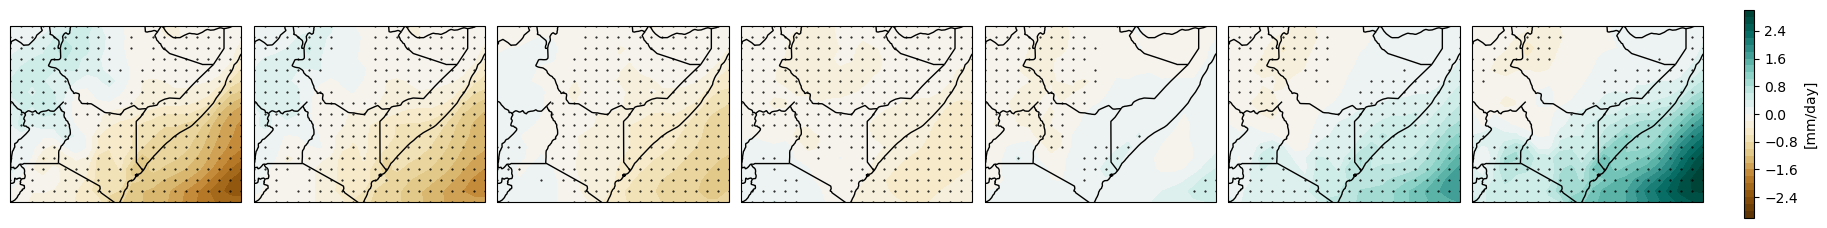

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


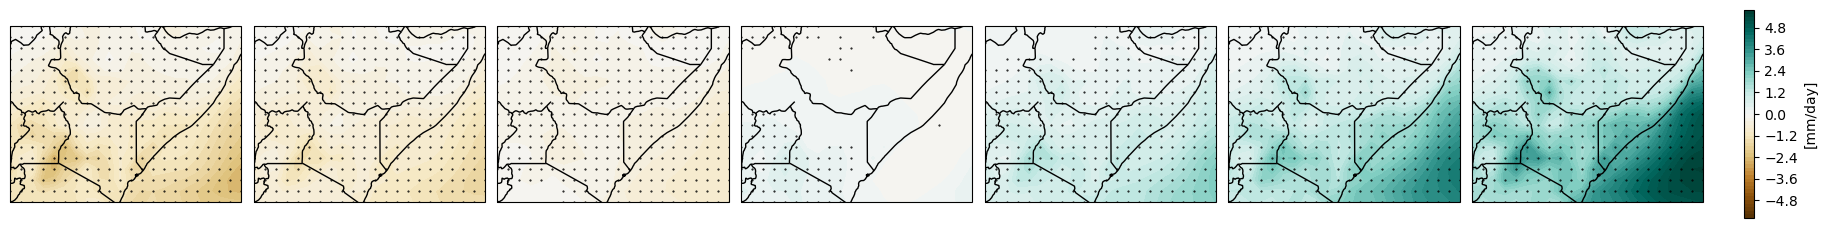

In [12]:
MIN_ABS_CORR = 0.5    # keep runs whose latent clearly represents the index (set to 0 to keep all)

keep_enso = run_info['enso_corr'].abs() >= MIN_ABS_CORR
keep_iod = run_info['iod_corr'].abs() >= MIN_ABS_CORR
print(f'ENSO: {keep_enso.sum()} of {len(run_info)} runs kept, '
      f'{(run_info.enso_sign < 0).sum()} flipped')
print(f'IOD:  {keep_iod.sum()} of {len(run_info)} runs kept, '
      f'{(run_info.iod_sign < 0).sum()} flipped')

enso_stacked = stack_aligned(response_pattern_enso, run_info['enso_sign'], keep=keep_enso)
iod_stacked = stack_aligned(response_pattern_iod, run_info['iod_sign'], keep=keep_iod)

enso_mean, enso_std, enso_significance = plot_response_significance(enso_stacked, 'enso')
iod_mean, iod_std, iod_significance = plot_response_significance(iod_stacked, 'iod')

### Latent dimensions

In [20]:
encoder, prediction_model, decoder, vae = build_model(42)
vae.load_weights(filepath+'weights/vae_trained_weights_0_42.h5')
[z1_mean_enc, z1_log_var_enc, z1_enc, z2_mean_enc, z2_log_var_enc, z2_enc, z3_mean_enc, z3_log_var_enc, z3_enc] = encoder.predict([x1, x2, x3], batch_size=batch_size)
[z1_decoded, z2_decoded, z3_decoded] = decoder.predict([z1_enc, z2_enc, z3_enc])
pz2_enc, pz3_z1z2_enc, pz3_enc = prediction_model.predict([z1_mean_enc, z2_mean_enc])

104/104 [==============================] - 0s 259us/step


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


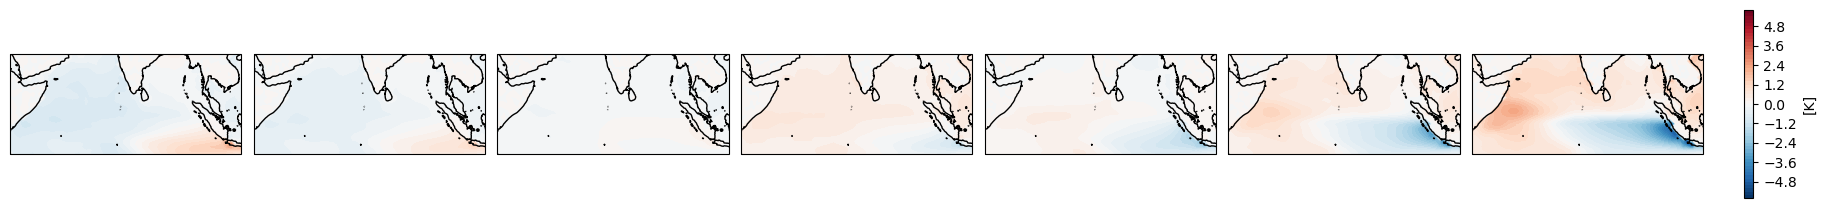

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value

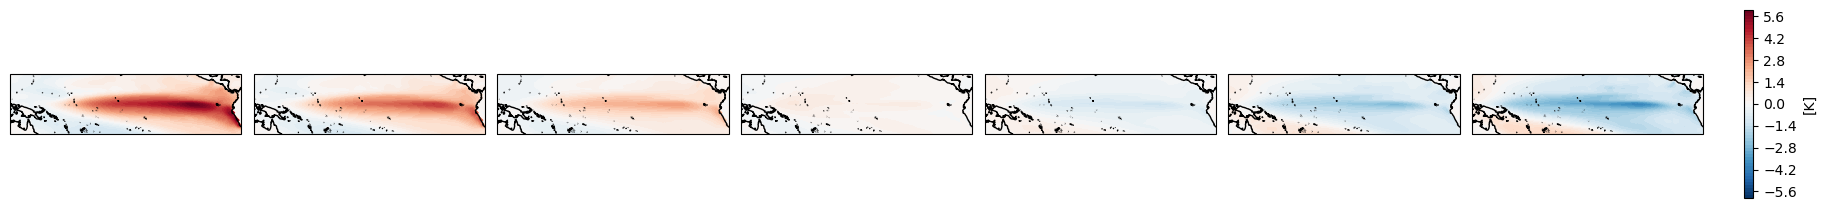

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


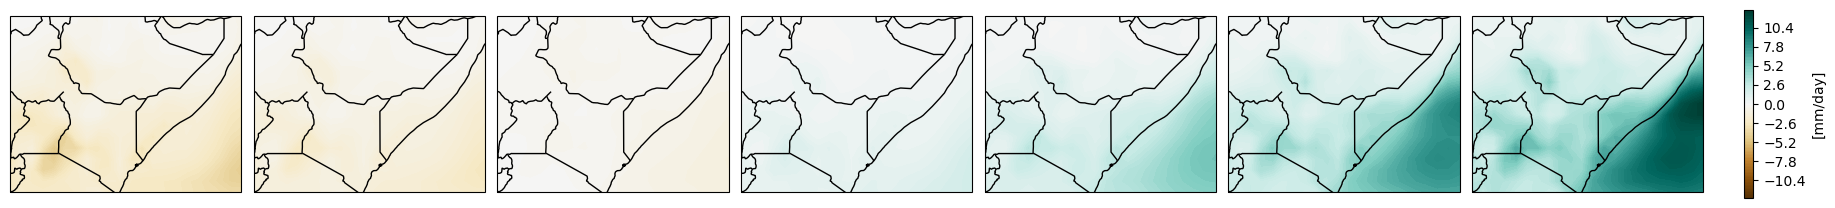

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


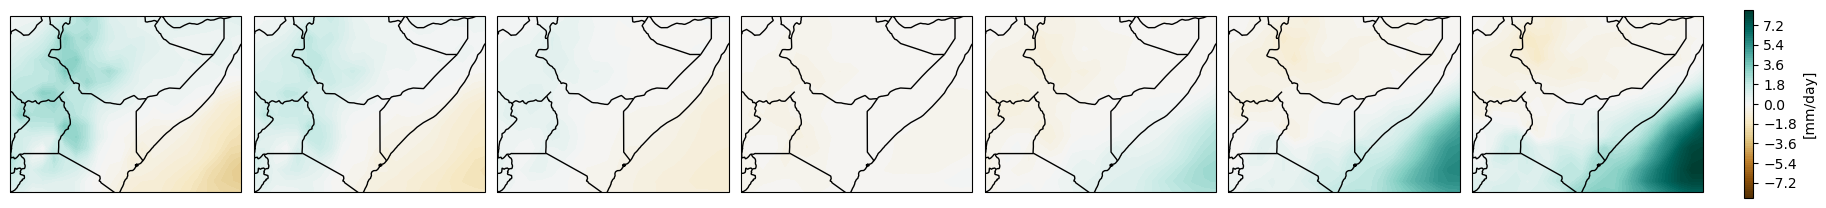

In [21]:
from IPython.display import display

MAKE_PLOTS = True

def plot_samples(samples, cfg, step=CONTOUR_STEP):
    """Row of maps with a shared colour bar; shown and closed immediately."""
    if not MAKE_PLOTS:
        return
    samples = samples.transpose('time', 'latitude', 'longitude')
    vmin, vmax = symmetric_limits(samples, step, cfg.get('vmax'))
    fig = visualise_contourplot_latent_legend(
        samples=samples, vmin=vmin, vmax=vmax, steps=step,
        color_scheme=cfg['cmap'], borders=cfg['borders'], col_number=samples.shape[0],
        projection=ccrs.PlateCarree(central_longitude=cfg['central_longitude']),
        unit_name=cfg['unit'])
    display(fig)
    plt.close(fig)

plot_samples(traverse_latent(1, z2_enc, [z1_enc, z3_enc], 0, decoder),
                PLOT_CFG['x2'])                                     # IOD
plot_samples(traverse_latent(0, z1_enc, [z2_enc, z3_enc], 0, decoder),
                PLOT_CFG['x1'])                                     # ENSO
for d in range(latent_dim_z3):                                   # precipitation
    plot_samples(traverse_latent(2, z3_enc, [z1_enc, z2_enc], d, decoder),
                 PLOT_CFG['x3'])

### R2 and ACC

In [25]:
def _corr_along(a, b, axis=None):
    """Pearson correlation of a and b along `axis` (None: over all elements).
    NaN where either input has zero variance."""
    a = a - a.mean(axis=axis, keepdims=True)
    b = b - b.mean(axis=axis, keepdims=True)
    num = (a * b).sum(axis=axis)
    den = np.sqrt((a * a).sum(axis=axis) * (b * b).sum(axis=axis))
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(den > 0, num / den, np.nan)


def acc_pooled(obs, pred):
    """Pearson correlation over all (time, grid point) pairs; same as
    climpred.metrics._pearson_r(obs, pred) without a `dim` argument."""
    return float(_corr_along(obs, pred, axis=None))


def acc_spatial(obs, pred):
    """Pattern correlation across grid points at each time step, averaged over time."""
    r = _corr_along(obs, pred, axis=1)
    return float(np.nanmean(r)) if np.isfinite(r).any() else np.nan


def acc_temporal(obs, pred):
    """Correlation over time at each grid point, averaged over grid points."""
    r = _corr_along(obs, pred, axis=0)
    return float(np.nanmean(r)) if np.isfinite(r).any() else np.nan


def r2_area_mean(obs, pred):
    """R² of the area-mean time series (unweighted mean over grid points)."""
    y_true, y_pred = obs.mean(axis=1), pred.mean(axis=1)
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))


def evaluate(obs, pred):
    """All metrics for flat (time, grid point) arrays of standardised precipitation."""
    obs = np.asarray(obs, dtype=np.float64)
    pred = np.broadcast_to(np.asarray(pred, dtype=np.float64), obs.shape)
    mse_map = np.mean((pred - obs) ** 2, axis=0)
    return {'r2': r2_area_mean(obs, pred),
            'acc': acc_pooled(obs, pred)}

In [26]:
import os
from tensorflow import keras

vae_metrics = []
n_time = x1_data.sizes['time']

for fold in range(N_FOLDS):
    train_idx, test_idx = contiguous_fold_indices(n_time, N_FOLDS, fold)

    for seed in SEEDS:
        weights_file = f'{WEIGHTS_DIR}vae_trained_weights_{fold}_{seed}.h5'
        if not os.path.exists(weights_file):
            print(f'missing, skipped: {weights_file}')
            continue

        keras.backend.clear_session()
        encoder, prediction_model, decoder, vae = build_model(seed)   # same settings as in training
        vae.load_weights(weights_file)

        # latent means are deterministic, so encode all time steps once and take subsets
        z1_mean, _, _, z2_mean, _, _, _, _, _ = encoder.predict([x1, x2, x3], batch_size=batch_size,
                                                                verbose=0)
        x3_pred = predict_x3_from_prior(prediction_model, decoder, z1_mean, z2_mean)

        for split, idx in (('train', train_idx), ('test', test_idx), ('full', slice(None))):
            vae_metrics.append({'model': 'DAG-VAE', 'fold': fold + 1, 'seed': seed, 'split': split,
                                **evaluate(x3[idx], x3_pred[idx])})

        print(f"fold {fold + 1} seed {seed}: test R2 {vae_metrics[-2]['r2']:.3f}  "
              f"ACC {vae_metrics[-2]['acc']:.3f}")

vae_metrics = pd.DataFrame(vae_metrics)

fold 1 seed 42: test R2 0.572  ACC 0.679
fold 1 seed 43: test R2 0.593  ACC 0.677
fold 1 seed 44: test R2 0.596  ACC 0.690
fold 1 seed 45: test R2 0.424  ACC 0.602
fold 1 seed 46: test R2 0.575  ACC 0.679
fold 1 seed 47: test R2 0.552  ACC 0.675
fold 1 seed 48: test R2 0.588  ACC 0.683
fold 1 seed 49: test R2 0.532  ACC 0.672
fold 1 seed 50: test R2 0.594  ACC 0.673
fold 1 seed 51: test R2 0.599  ACC 0.681
fold 2 seed 42: test R2 0.410  ACC 0.573
fold 2 seed 43: test R2 0.579  ACC 0.669
fold 2 seed 44: test R2 0.564  ACC 0.660
fold 2 seed 45: test R2 0.564  ACC 0.656
fold 2 seed 46: test R2 0.476  ACC 0.616
fold 2 seed 47: test R2 0.589  ACC 0.667
fold 2 seed 48: test R2 0.503  ACC 0.633
fold 2 seed 49: test R2 0.552  ACC 0.656
fold 2 seed 50: test R2 0.554  ACC 0.659
fold 2 seed 51: test R2 0.565  ACC 0.659
fold 3 seed 42: test R2 0.583  ACC 0.672
fold 3 seed 43: test R2 0.640  ACC 0.703
fold 3 seed 44: test R2 0.573  ACC 0.672
fold 3 seed 45: test R2 0.594  ACC 0.683
fold 3 seed 46: 

In [28]:
METRICS = ['r2', 'acc']


def mean_std(df, by):
    """'mean ± std' of the metrics, grouped by `by`."""
    g = df.groupby(by, sort=False)[METRICS]
    return g.mean().round(3).astype(str) + ' ± ' + g.std(ddof=0).round(3).astype(str)


# (a) over all runs (folds × seeds)
summary_all_runs = mean_std(vae_metrics, 'split')

# (b) comparable with the baselines: average the seeds within each fold,
#     then mean ± std over folds
fold_means = vae_metrics.groupby(['split', 'fold'], sort=False)[METRICS].mean().reset_index()
summary_by_fold = mean_std(fold_means, 'split')

# per-fold detail
per_fold = vae_metrics.groupby(['split', 'fold'], sort=False)[METRICS].mean().round(3)

display(summary_all_runs)
display(summary_by_fold)

vae_metrics.to_csv(filepath + 'vae_metrics_per_run.csv', index=False)
summary_by_fold.to_csv(filepath + 'vae_summary_by_fold.csv')

,r2,acc
split,,
train,0.561 ± 0.041,0.662 ± 0.02
test,0.56 ± 0.043,0.662 ± 0.023
full,0.561 ± 0.041,0.662 ± 0.02


,r2,acc
split,,
train,0.561 ± 0.018,0.662 ± 0.008
test,0.56 ± 0.017,0.662 ± 0.012
full,0.561 ± 0.017,0.662 ± 0.008
